# Tutorial 1

This notebook mirrors the Part 1 case studies in the simplest possible setting: a scalar linear ODE, weak-form SINDy, and multi-fidelity weighting performed directly in weak space.

### Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pysindy as ps
from pysindy.feature_library import WeakPDELibrary
from tqdm import tqdm

from mfsindy import WeightedWeakPDELibrary

warnings.filterwarnings("ignore")


## 1. Synthetic test problem: scalar linear ODE

Consider
$$
\frac{du}{dt} = \lambda u, \qquad \lambda = -0.5.
$$

The analytic solution with initial condition $u(0)=u_0$ is
$$
u(t) = u_0 e^{\lambda t}.
$$

As in the Part 1 case studies, we observe multiple trajectories split into two groups:

- high-fidelity (HF): fewer trajectories with smaller noise,
- low-fidelity (LF): more trajectories with larger noise.

The goal is to identify the coefficient vector associated with the candidate library
$$
\Phi(u) = [u, u^2],
$$
whose true coefficient vector is $[\lambda^\star, 0] = [-0.5, 0]$.

In [2]:
lam_true = -0.5
T_final = 5.0
Nt = 400
t_eval = np.linspace(0.0, T_final, Nt)
XT = t_eval[:, None]


def solve_trajectory(u0):
    """Analytic solution with shape (Nt, 1)."""
    return (u0 * np.exp(lam_true * t_eval))[:, None]


## 2. Multi-fidelity ensembles

Each trajectory has a constant variance over time, but the variance depends on its fidelity group. This gives the trajectory-wise homogeneous-noise regime discussed in the methodology notes.

We will compare four estimators:

- `HF`: weak-form fit using only HF trajectories,
- `LF`: weak-form fit using only LF trajectories,
- `MF`: stacked weak-form fit using HF and LF equally,
- `MF_w`: stacked weak-form fit where each trajectory is whitened with its own variance level through `WeightedWeakPDELibrary`.


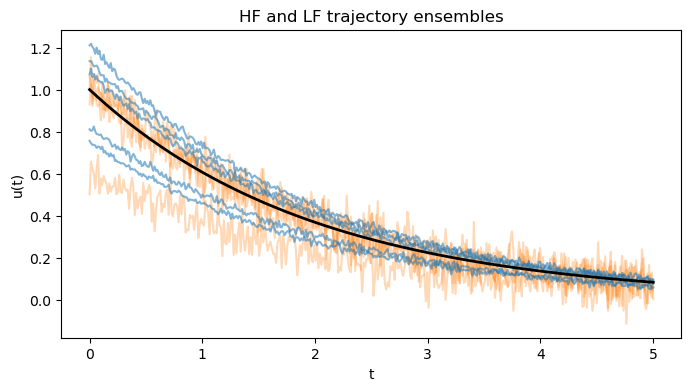

In [3]:
n_hf = 5
n_lf = 20
sigma_hf = 0.01
sigma_lf = 0.06


def generate_batch(n_traj, noise_std, seed):
    rng = np.random.default_rng(seed)
    trajectories = []
    for _ in range(n_traj):
        u0 = rng.uniform(0.5, 1.5)
        clean = solve_trajectory(u0)
        noisy = clean + rng.normal(loc=0.0, scale=noise_std, size=clean.shape)
        trajectories.append(noisy)
    return trajectories


hf_batch = generate_batch(n_hf, sigma_hf, seed=0)
lf_batch = generate_batch(n_lf, sigma_lf, seed=1)
u_ref = solve_trajectory(1.0)

plt.figure(figsize=(8, 4))
for traj in lf_batch[:4]:
    plt.plot(t_eval, traj[:, 0], color="tab:orange", alpha=0.30)
for traj in hf_batch:
    plt.plot(t_eval, traj[:, 0], color="tab:blue", alpha=0.55)
plt.plot(t_eval, u_ref[:, 0], color="black", linewidth=2)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("HF and LF trajectory ensembles")
plt.show()


## 3. Weak-form blocks and weak-space stacking

This is the key Part 1 construction.

For each trajectory, we build a weak regression block
$$
\Theta_k \xi \approx V_k,
$$
where both $\Theta_k$ and $V_k$ come from `WeakPDELibrary` or `WeightedWeakPDELibrary`.

The weighted library performs GLS whitening in weak space using the supplied variance field. Since each trajectory here has a constant variance over time, the variance field is simply a constant array with shape $(N_t, 1)$.

In [4]:
base_library = ps.PolynomialLibrary(degree=2, include_bias=False)


def make_weak_library(variance_field=None):
    common_kwargs = dict(
        function_library=base_library,
        derivative_order=1,
        spatiotemporal_grid=XT,
        is_uniform=True,
        include_bias=False,
    )
    if variance_field is None:
        return WeakPDELibrary(**common_kwargs)
    return WeightedWeakPDELibrary(
        spatiotemporal_weights=variance_field,
        **common_kwargs,
    )


def weak_block(traj, variance_level=None):
    variance_field = None
    if variance_level is not None:
        variance_field = np.full(traj.shape[:-1], variance_level**2, dtype=float)
    lib = make_weak_library(variance_field=variance_field)
    theta = np.asarray(lib.fit_transform([traj])[0])
    rhs = np.asarray(lib.convert_u_dot_integral(traj))
    return theta, rhs


def optimizer_factory():
    return ps.EnsembleOptimizer(
        ps.STLSQ(threshold=0.05, alpha=1e-3),
        bagging=True,
        n_models=30,
    )


def median_coefficients(optimizer):
    coef_list = getattr(optimizer, "coef_list", None)
    if coef_list is not None:
        arr = np.asarray(coef_list)
        if arr.ndim == 3:
            return np.median(arr, axis=0)
    return np.asarray(optimizer.coef_)


def fit_stacked(theta_blocks, rhs_blocks):
    optimizer = optimizer_factory()
    optimizer.fit(np.vstack(theta_blocks), np.vstack(rhs_blocks))
    return np.asarray(median_coefficients(optimizer), dtype=float).ravel()


def fit_multi_trajectory_weak_models(hf, lf):
    theta_hf = []
    rhs_hf = []
    theta_lf = []
    rhs_lf = []
    theta_hf_w = []
    rhs_hf_w = []
    theta_lf_w = []
    rhs_lf_w = []

    for traj in hf:
        theta, rhs = weak_block(traj, variance_level=None)
        theta_hf.append(theta)
        rhs_hf.append(rhs)
        theta_w, rhs_w = weak_block(traj, variance_level=sigma_hf)
        theta_hf_w.append(theta_w)
        rhs_hf_w.append(rhs_w)

    for traj in lf:
        theta, rhs = weak_block(traj, variance_level=None)
        theta_lf.append(theta)
        rhs_lf.append(rhs)
        theta_w, rhs_w = weak_block(traj, variance_level=sigma_lf)
        theta_lf_w.append(theta_w)
        rhs_lf_w.append(rhs_w)

    return {
        "HF": fit_stacked(theta_hf, rhs_hf),
        "LF": fit_stacked(theta_lf, rhs_lf),
        "MF": fit_stacked(theta_hf + theta_lf, rhs_hf + rhs_lf),
        "MF_w": fit_stacked(theta_hf_w + theta_lf_w, rhs_hf_w + rhs_lf_w),
    }


coef_map = fit_multi_trajectory_weak_models(hf_batch, lf_batch)
for name in ["HF", "LF", "MF", "MF_w"]:
    print(name, coef_map[name])


HF [-0.50017009  0.        ]
LF [-0.50596084  0.        ]
MF [-0.50425449  0.        ]
MF_w [-0.50100364  0.        ]


For a single batch, `MF_w` should typically move the linear coefficient estimate back toward $\lambda^\star=-0.5$ relative to the unweighted `MF` fit, because the noisier LF weak blocks are whitened more aggressively.

## 4. Monte Carlo comparison

As in the Part 2 tutorial, we repeat the identification experiment over many random draws and compare:

- the linear coefficient error $|\hat{\lambda} - \lambda^\star|$,
- the spurious quadratic coefficient magnitude $|\hat{\xi}_2|$.

This time, however, the comparison happens between stacked weak-space estimators.

In [5]:
n_trials = 200
err_lam = {name: [] for name in ["HF", "LF", "MF", "MF_w"]}
spur_quad = {name: [] for name in ["HF", "LF", "MF", "MF_w"]}

for trial in tqdm(range(n_trials)):
    hf_batch = generate_batch(n_hf, sigma_hf, seed=1000 + trial)
    lf_batch = generate_batch(n_lf, sigma_lf, seed=4000 + trial)
    coef_map = fit_multi_trajectory_weak_models(hf_batch, lf_batch)
    for name, coef in coef_map.items():
        err_lam[name].append(abs(coef[0] - lam_true))
        spur_quad[name].append(abs(coef[1]))

err_lam = {k: np.asarray(v, dtype=float) for k, v in err_lam.items()}
spur_quad = {k: np.asarray(v, dtype=float) for k, v in spur_quad.items()}


100%|██████████| 200/200 [13:20<00:00,  4.00s/it]


In [6]:
def summary_stats(name, linear_error, quadratic_error):
    print(f"{name}:")
    print(f"  |lambda_hat - lambda*| mean   = {linear_error.mean():.3e}")
    print(f"  |lambda_hat - lambda*| median = {np.median(linear_error):.3e}")
    print(f"  |xi_2| mean                  = {quadratic_error.mean():.3e}")
    print(f"  |xi_2| median                = {np.median(quadratic_error):.3e}")
    print()


for name in ["HF", "LF", "MF", "MF_w"]:
    summary_stats(name, err_lam[name], spur_quad[name])


HF:
  |lambda_hat - lambda*| mean   = 1.950e-03
  |lambda_hat - lambda*| median = 1.710e-03
  |xi_2| mean                  = 0.000e+00
  |xi_2| median                = 0.000e+00

LF:
  |lambda_hat - lambda*| mean   = 7.500e-03
  |lambda_hat - lambda*| median = 5.088e-03
  |xi_2| mean                  = 4.315e-03
  |xi_2| median                = 0.000e+00

MF:
  |lambda_hat - lambda*| mean   = 5.079e-03
  |lambda_hat - lambda*| median = 3.580e-03
  |xi_2| mean                  = 1.709e-03
  |xi_2| median                = 0.000e+00

MF_w:
  |lambda_hat - lambda*| mean   = 4.762e-04
  |lambda_hat - lambda*| median = 3.857e-04
  |xi_2| mean                  = 0.000e+00
  |xi_2| median                = 0.000e+00



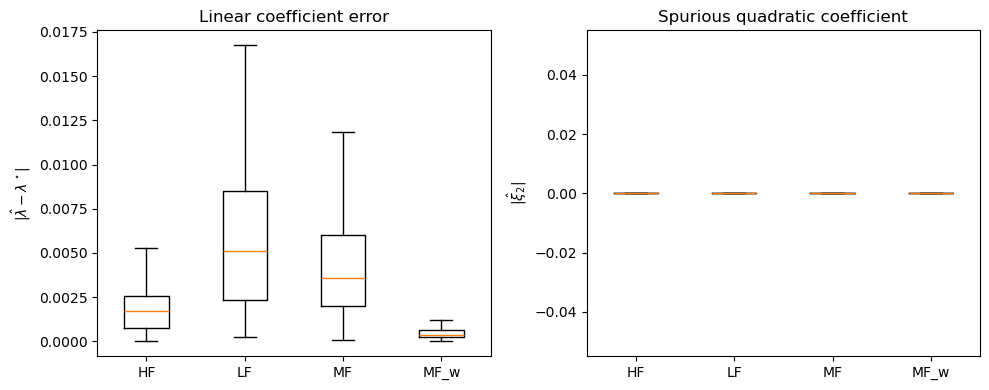

In [7]:
labels = ["HF", "LF", "MF", "MF_w"]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot([err_lam[name] for name in labels], labels=labels, showfliers=False)
plt.ylabel(r"$|\hat{\lambda} - \lambda^\star|$")
plt.title("Linear coefficient error")

plt.subplot(1, 2, 2)
plt.boxplot([spur_quad[name] for name in labels], labels=labels, showfliers=False)
plt.ylabel(r"$|\hat{\xi}_2|$")
plt.title("Spurious quadratic coefficient")

plt.tight_layout()
plt.show()


## 5. Interpretation

This notebook now matches the structure of the Part 1 case experiments more closely:

- build one weak block per trajectory,
- optionally whiten each weak block through `WeightedWeakPDELibrary`,
- stack HF and LF weak systems,
- compare `HF`, `LF`, `MF`, and `MF_w` in coefficient space.

So the weighting is no longer a simple sample-weight trick on raw trajectories. It is the same weak-space GLS idea used in the case notebooks, specialized to a one-dimensional ODE where the noise level is constant within each trajectory.